<table><tbody><tr><th><p><img alt="Emblema" src="https://cdn6.aptoide.com/imgs/6/f/4/6f4821daa840da8fe971445350759fe5_icon.png" style="width:150px;"></p></th><th><p><strong>Inteligencia Artificial</strong></p><p><strong>Grado en Ingeniería Informática en Sistemas de Información – Curso 2024/2025</strong></p><p><strong>ENSEÑANZAS PRÁCTICAS Y DE DESARROLLO</strong></p><h1>EPD 2: Machine Learning - Regresión Lineal </h1></th></tr></tbody></table>

____

## Objetivos
- Implementación en Python de un algoritmo de Regresión Lineal univariable y multivariable y su aplicación a datos.

___

## Bibliografía Básica
- Machine Learning. Tom Mitchell. MacGraw-Hill, 1997

___

## **Regresión Lineal Univariable**

Implementar y aplicar regresión lineal con una variable para predecir los beneficios de un restaurante ambulante. Ponte en el papel del Director Ejecutivo de una franquicia de este tipo de restaurantes y estás considerando diferentes ciudades para la apertura de un nuevo establecimiento. La cadena ya cuenta con restaurantes en varias ciudades, y dispone de los datos de los beneficios y las poblaciones de las ciudades. Deberías utilizar los datos como ayuda para seleccionar en qué ciudad poner el siguiente establecimiento.

El fichero ex1data1.txt contiene los datos para nuestro problema de regresión lineal. La primera columna es la población de una ciudad y la segunda es el beneficio de un establecimiento en esa ciudad. Un valor negativo de beneficio indica una pérdida.

Utilizar este mismo notebook para ir incorporando el código y las llamadas a las funciones que se piden en los siguientes ejercicios. Apóyese además en los scripts .py adicionales, implementando las funciones que considere oportunas.

#### EJERCICIO 01.
Normalmente, antes de empezar cualquier tarea se suele visualizar el conjunto de datos.
Añadir el código necesario para cargar los datos, e implementar la función plotData(X,y) en el archivo plotData.py para representar los datos gráficamente.

##### Solución:

In [1]:
#librerías (comunes a todos los ejercicios)
import pandas as pd
import numpy as np
import sklearn.linear_model
import matplotlib.pyplot as plt

#Uni
from plotData import *
from computeCost import computeCost

#Multi
#from computeCostMulti import computeCostMulti
#from featureNormalize import featureNormalize
#from gradientDescentMulti import gradientDescentMulti
# from normalEqn import normalEqn
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from sklearn import linear_model
from sklearn import metrics

In [5]:
# Función lectura fichero
def read_file(file_name, feature_names, target_name):
    print('Cargando datos...', file_name)

    file = pd.read_csv(file_name, names=feature_names + [target_name])

    X = file[feature_names]
    y = file[[target_name]]

    return X, y

Cargando datos... data/ex1data1.txt


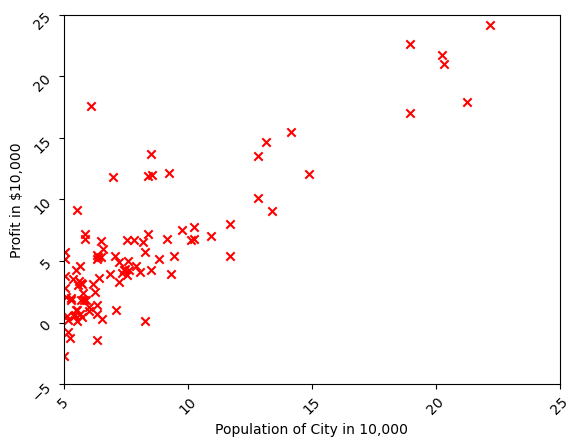

In [6]:
# Carga del conjunto de datos
X, y = read_file('data/ex1data1.txt', ['Poblacion'], 'Beneficio')

# Llamada a la función plot implementada
plotData(X,y)

#### EJERCICIO 02.
El objetivo de la regresión lineal es minimizar el coste de la función:

![image.png](attachment:5c0d30eb-272a-4faf-a82d-7a2213ee99ed.png)

Implementar la función **computeCost(X, y, theta)** de manera que devuelva el valor del coste. La matriz X es la matriz formada por la población de cada ciudad e y es el vector formado por los beneficios del establecimiento de cada ciudad. Para facilitar las operaciones vectorizadas, añada una columna con todos sus elementos a 1 a la matriz X como primera columna, de esta manera se podrá calcular la hipótesis h que viene dada por el modelo lineal:

![image.png](attachment:52439e61-7ddd-49ee-bcea-13dadbdad313.png)

Para comenzar inicializar los parámetros theta a 0. El resultado del coste inicial debe ser 32,07.

##### Solución:

In [7]:
# Some gradient descent settings: Añada una columna con todos sus elementos a 1 a la matriz X como primera columna e inicializar los parámetros theta a 0
ones = np.ones((len(y),1))  # Creamos una matriz de unos
X['uno'] = ones

X = X[['uno', 'Poblacion']]

theta = np.zeros((2,1), dtype = float)
print("Theta inizialiation: \n", theta)

J_base = computeCost(X, y, theta) # Compute and display initial cost

print("\nResult EJ2: Cost = ", J_base)

Theta inizialiation: 
 [[0.]
 [0.]]

Result EJ2: Cost =  32.072733877455676


#### EJERCICIO 03.
Implementar el método de descenso del gradiente (ver documento de EB, p. 42). La función recibirá como parámetro, además de los datos X e y, los parámetros theta, alpha y el número de iteraciones. Estos dos últimos se pueden inicializar a 0,01 y 1500 respectivamente. La función deberá devolver los parámetros theta finales y un histórico con el coste en cada iteración. Mostrar por pantalla los valores de theta. Crear la función plotIterationsVsCost() para comprobar que el descenso del gradiente para los parámetros indicados funciona correctamente. Se representará el número de iteraciones vs el coste.

##### Solución:

In [8]:
# El descenso de gradiente 
def gradientDescent(X, y, theta, alpha, iterations):
    # Initialize some useful parameters
    m = len(y) # number of training examples
    current_iter = [] # Empty arrays to create a history dataframe
    current_cost = []

    # ====================== YOUR CODE HERE ======================
    # Instructions: Perform a single gradient step on the parameter vector theta
    # Hint: While debugging, it can be useful to print out the values
    #       of the cost function (computeCost) and gradient here.
    # We can do it with numpy matrix or dataframes: X = np.matrix(X.values) y = np.matrix(y.values)
    for iter in range(iterations):
        h = np.dot(X, theta)
        theta = theta - alpha*(1/m)*(np.dot(X.T, (h-y)))
        
        current_iter.append(iter)
        current_cost.append(computeCost(X, y, theta))


    J_history = pd.DataFrame({'iteracion': current_iter, 'cost':current_cost})

    return theta, J_history


Theta found by gradient descent: 
 [[-3.63029144]
 [ 1.16636235]]

Cost reached at iteration number  1500 :  1499    4.483388
Name: cost, dtype: float64


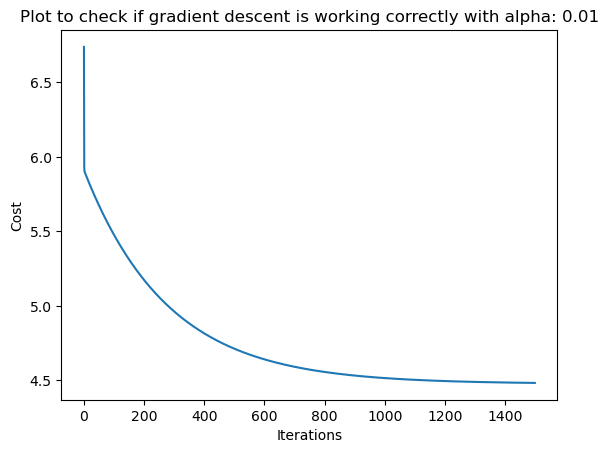

In [9]:
# Some gradient descent settings
iterations = 1500
alpha = 0.01
theta_opt, J_history = gradientDescent(X, y, theta, alpha, iterations)
# print theta to screen
print('Theta found by gradient descent: \n', theta_opt)
print('\nCost reached at iteration number ', iterations, ": ", J_history[J_history['iteracion']==1499]['cost']) # El 1499 que pinta es la fila
plotIterationsVsCost(J_history, alpha)

#### EJERCICIO 04.
Representar gráficamente los resultados obtenidos y calcular la predicción de beneficios para una población de 35000 y 70000 habitantes. Mantener la figura anterior para poder comprobar la diferencia con los datos originales como en la figura de la derecha.

##### Solución:

In [14]:
# Plot the linear fit
plotData_linearRegression(X, y, theta_opt)
print('Theta found by gradient descent: \n', theta_opt)

# Predict values for population sizes of 35,000 and 70,000
predict1 = np.dot([1,3.5],theta_opt)
predict1_b = np.dot(theta_opt.T, [1,35000])
print('\nFor population = 35,000, we predict a profit of ', predict1 * 10000)
print('For population = 35,000, we predict a profit of ', predict1_b )

predict2 = np.dot([1,7],theta_opt)
predict2_b = np.dot(theta_opt.T, [1,7])
print('\nFor population = 70,000, we predict a profit of ', predict2 * 10000)
print('For population = 70,000, we predict a profit of ', predict2_b * 10000)


print("\n")
datos_test = np.array([1,3.5],[1,7])
print(np.dot(datos_test, theta_opt)*1000)

KeyError: 'poblacion'

## **Regresión Lineal Multivariable**

Implementar regresión lineal con múltiples variables para predecir los precios de casas. Suponer que queremos vender nuestra casa y queremos saber cuál sería un buen precio de mercado. Una opción sería recolectar información de ventas de casas recientes y crear un modelo de precios de casas.

El fichero ex1data2.txt contiene un conjunto de entrenamiento de precios de casas en una ciudad estadounidense. La primera columna corresponde con el tamaño de la casa (en pies cuadrados), la segunda columna indica el número de dormitorios, y la tercera el precio de la casa.

Antes de nada, muestra las diez primeras filas de datos y a continuación:

1. Implementar una función para normalizar los datos de la matriz X que utilice la desviación estándar.
2. Si la función de coste implementada en la práctica anterior no se puede utilizar para múltiples variables, codificar una nueva. En este caso también hay que añadir una primera columna a la matriz X con todos sus elementos a 1.
3. Lo mismo ocurre con el método del gradiente, ver si se puede reutilizar o hay que implementar uno nuevo.
4. Mostrar el gráfico de convergencia que se observa en la figura obtenido con alpha igual a 0.03 y 200 iteraciones.
5. Predecir el precio de una casa de 1650 pies
cuadrados y 3 habitaciones.
6. Calcular los parámetros theta mediante el uso de la ecuación normal, y predecir nuevamente el precio de la vivienda con los valores anteriores.

In [2]:
#Lectura del fichero
def read_file(file_name, feature_names, target_name):
    print('Cargando datos...', file_name)

    file = pd.read_csv(file_name, names=feature_names + [target_name])

    X = file[feature_names]
    y = file[[target_name]]

    return X, y

In [4]:
# Mostrar las 10 primeras filas del dataset (tanto de X como de y)
# Cargar los datos del archivo ex1data2.txt
X_multi, y_multi = read_file('data/ex1data2.txt', ['Tamaño', 'Habitaciones'], 'Precio')

# Mostrar las 10 primeras filas
print("Primeras 10 filas de X (características):")
print(X_multi.head(10))

print("\nPrimeras 10 filas de y (precio):")
print(y_multi.head(10))

Cargando datos... data/ex1data2.txt
Primeras 10 filas de X (características):
   Tamaño  Habitaciones
0    2104             3
1    1600             3
2    2400             3
3    1416             2
4    3000             4
5    1985             4
6    1534             3
7    1427             3
8    1380             3
9    1494             3

Primeras 10 filas de y (precio):
   Precio
0  399900
1  329900
2  369000
3  232000
4  539900
5  299900
6  314900
7  198999
8  212000
9  242500


In [ ]:
# 1. NORMALIZAR LOS DATOS CON LA DESVIACIÓN ESTÁND


In [ ]:
# 2. CODIFICAR NUEVA FUNCIÓN DE COSTE (EN COMPUTECOSTMULTI.PY) Y AÑADIR COLUMNA DE UNOS


In [ ]:
# 3. DESCENSO DEL GRADIENTE --> función gradientDescentMulti
# Elegir parámetros
alpha = 0.03
num_iters = 200

# Inicializar Theta a 0 y ejecutar el descenso del gradiente


In [ ]:
# 4. GRÁFICO DE CONVERGENCIA Y MOSTRAR LOS VALORES THETA


In [ ]:
# 5. PREDECIR EL PRECIO DE UNA CASA DE 1650 PIES CUADRADOS Y 3 HABITACIONES
# Los datos hay que normalizarlos usando la media y la desviación antes de tomarlos como entrada en la regresión


In [ ]:
# 6. ECUACIÓN NORMAL


## Problemas

#### PROBLEMA 01.
En el caso de estudio utilizado en la regresión univariable, probar con diferentes valores de alpha (0.1, 0.03, 0.01, …). Representar y comparar los diferentes resultados obtenidos con la función plotIterationsVsCost() para comprobar qué valores de alpha son válidos y cuáles no. Finalmente, utilizar los mejores valores de theta para predecir de nuevo los beneficios para una población de 35000 y 70000 habitantes. Curiosidad: realizar también ambas predicciones utilizando diferentes modelos de regresión lineal de la librería sklearn (sklearn.linear_model) como por ejemplo: LinearRegression(), Ridge() o Lasso().

##### Solución:

#### PROBLEMA 02.
Incluir el código necesario en main.py para obtener las gráficas de la función de coste que se muestran en el pdf de la práctica. Para ello, utilizar los comandos plot_surface y contour.


##### Solución:

#### PROBLEMA 03.
Utilizar la regresión lineal para predecir los precios de casas. Suponer que queremos vender nuestra casa y queremos saber cuál sería un buen precio de mercado. Una opción sería recolectar información de ventas de casas recientes y crear un modelo de precios de casas.

El fichero ex1data2.txt contiene un conjunto de entrenamiento de precios de casas en una ciudad estadounidense. La primera columna corresponde con el tamaño de la casa (en pies cuadrados), la segunda columna indica el número de dormitorios, y la tercera el precio de la casa.

Utilizando la función de coste y el método de descenso del gradiente antes implementados, indica cuál de los dos atributos determina mejor el precio de la casa. Considerar los valores 0,03 y 200 para alpha y el número de iteraciones respectivamente. Como en el ejercicio 4, visualizar los resultados obtenidos con cada una de las opciones o atributos.

##### Solución:

#### PROBLEMA 04.
En el caso de estudio utilizado en la regresión multivariable, probar con diferentes valores de alpha, como por ejemplo 0.3, 0.1, 0.03, 0.01,… usando la normalización de los datos con desviación estándar (Ejercicio 1). Representar los gráficos de convergencia (Ejercicio 4) y comparar los diferentes resultados obtenidos. Finalmente, utilizar los mejores valores de theta para predecir el precio de una casa de 1650 pies cuadrados y 3 habitaciones. Además, se podrían comparar estos resultados con los obtenidos en la ampliación de problemas de la práctica anterior aplicando regresión lineal con una solo variable.

##### Solución:

#### PROBLEMA 05.
Se va a utilizar la librería scikit learn (también conocida como sklearn) para dividir en dos partes los conjuntos de datos X e y de ex1data2.txt: una parte será el conjunto de entrenamiento y otro de test, contiendo el primero el 70% de los ejemplos elegidos aleatoriamente, mientras que el segundo contendrá el resto. Para ello utilizar la función train_test_split(). Recuerde normalizar los valores.

Al finalizar deberías tener Xtrain, Xtest, ytrain e ytest.



##### Solución: